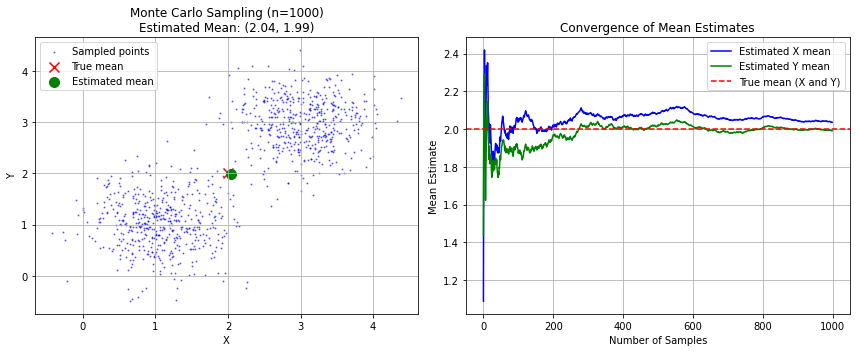

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Number of points to sample
n_points = 1000

# Define a simple 2D multimodal normal distribution (mixture of two Gaussians)
# First Gaussian: centered at (1, 1) with standard deviation 0.5
# Second Gaussian: centered at (3, 3) with standard deviation 0.5
# Equal weight (0.5) for each Gaussian
mixture_choice = np.random.choice([0, 1], size=n_points, p=[0.5, 0.5])
x = np.where(mixture_choice == 0,
             np.random.normal(loc=1, scale=0.5, size=n_points),
             np.random.normal(loc=3, scale=0.5, size=n_points))
y = np.where(mixture_choice == 0,
             np.random.normal(loc=1, scale=0.5, size=n_points),
             np.random.normal(loc=3, scale=0.5, size=n_points))

# Monte Carlo: Estimate the mean of the distribution by averaging the points
mean_x = np.cumsum(x) / np.arange(1, n_points + 1)
mean_y = np.cumsum(y) / np.arange(1, n_points + 1)
final_mean_x = mean_x[-1]
final_mean_y = mean_y[-1]

# True mean of the mixture (weighted average of the two Gaussian means)
true_mean_x = 0.5 * 1 + 0.5 * 3  # (0.5 * 1) + (0.5 * 3) = 2
true_mean_y = 0.5 * 1 + 0.5 * 3  # Same for y

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Scatter plot of sampled points
ax1.scatter(x, y, c='blue', s=1, alpha=0.5, label='Sampled points')
ax1.scatter(true_mean_x, true_mean_y, c='red', s=100, marker='x', label='True mean')
ax1.scatter(final_mean_x, final_mean_y, c='green', s=100, marker='o', label='Estimated mean')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title(f'Monte Carlo Sampling (n={n_points})\nEstimated Mean: ({final_mean_x:.2f}, {final_mean_y:.2f})')
ax1.legend()
ax1.grid(True)

# Plot 2: Convergence of mean estimates
ax2.plot(mean_x, label='Estimated X mean', color='blue')
ax2.plot(mean_y, label='Estimated Y mean', color='green')
ax2.axhline(y=true_mean_x, color='red', linestyle='--', label='True mean (X and Y)')
ax2.set_xlabel('Number of Samples')
ax2.set_ylabel('Mean Estimate')
ax2.set_title('Convergence of Mean Estimates')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()